# HPV Vaccination Results Explorer

This notebook provides tools for exploring the saved MultiSim objects from vaccination scenario analyses.

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sciris as sc
import hpvsim as hpv
from pathlib import Path

# Add project directories to path
project_dir = Path().absolute().parent.parent  # Go up from analysis/ to main project
sys.path.insert(0, str(project_dir))
sys.path.insert(0, str(project_dir / "hpv_scenarios"))

# Import project modules
import analyzers as an
import utils as ut
from core.seed_batch_manager import SeedBatchManager

print(f"HPVsim version: {hpv.__version__}")
print(f"Project directory: {project_dir}")

HPVsim 2.2.1 (2025-05-29) — © 2023-2025 by IDM
HPVsim version: 2.2.1
Project directory: /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster


## Load a Sample MultiSim Object

In [3]:
# Define paths
results_dir = project_dir / "hpv_scenarios" / "results" / "vaccination"
filestem = "_jul22"  # Change this to match your files

print(f"Results directory: {results_dir}")
print(f"Directory exists: {results_dir.exists()}")

# List available result files
pattern = str(results_dir / f"*{filestem}.obj")
result_files = glob.glob(pattern)

print(f"\nFound {len(result_files)} result files:")
for i, filepath in enumerate(result_files[:10]):  # Show first 10
    filename = os.path.basename(filepath)
    print(f"  {i+1:2d}. {filename}")

if len(result_files) > 10:
    print(f"  ... and {len(result_files) - 10} more files")

Results directory: /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/results/vaccination
Directory exists: True

Found 24 result files:
   1. cote_d_ivoire_vx_quinquennial_9-14_HR_jul22.obj
   2. zambia_vx_triennial_9-12_HR_jul22.obj
   3. zambia_vx_annual_9-10_HR_jul22.obj
   4. cote_d_ivoire_vx_quadrennial_9-13_NAT_jul22.obj
   5. zambia_vx_biennial_9-11_HR_jul22.obj
   6. cote_d_ivoire_vx_biennial_9-11_NAT_jul22.obj
   7. cote_d_ivoire_vx_annual_9-10_NAT_jul22.obj
   8. cote_d_ivoire_vx_triennial_9-12_NAT_jul22.obj
   9. zambia_baseline_national_jul22.obj
  10. cote_d_ivoire_baseline_high_risk_jul22.obj
  ... and 14 more files


In [ ]:
for file in result_files:
    if not file.endswith(".obj"):
        print(f"Skipping non-obj file: {file}")
        continue

    try:
        msim = sc.loadobj(file)
        print(f"Loaded simulation from {file}")
        msim.shrink()
        #shrunk_file = file.replace(".obj", "_shrunk.obj")
        sc.saveobj(file, msim)
        print(f"Shrunk and saved simulation to {file}")
    except Exception as e:
        print(f"Error loading {file}: {e}")
        continue



Loaded simulation from /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/results/vaccination/cote_d_ivoire_vx_quinquennial_9-14_HR_jul22.obj
Shrunk and saved simulation to /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/results/vaccination/cote_d_ivoire_vx_quinquennial_9-14_HR_jul22.obj
Loaded simulation from /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/results/vaccination/zambia_vx_triennial_9-12_HR_jul22.obj
Shrunk and saved simulation to /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/results/vaccination/zambia_vx_triennial_9-12_HR_jul22.obj
Loaded simulation from /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/results/vaccination/zambia_vx_annual_9-10_HR_jul22.obj
Shrunk and saved simulation to /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/results/vaccination/zambia_vx_annual_9-10_HR_jul22.obj
Loaded simulation from /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_s

Bad pipe message: %s [b'\xf0\xc1\xe4\xb4q\x10\xed\xe7\x83#B\xddh\x0e\x0f\xcc\x8c\xd3\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00']
Bad pipe message: %s [b'g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xba\x00\xbb\x00\xbc\x00\xbd']
Bad pipe message: %s [b'Dr\x8f\xce\x1a\xbc\x13\xb2\x9b}\xbc\xc1*Y\xda)Tn\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x

In [ ]:
sim = sc.loadobj()

In [ ]:
import sys

def get_size(obj, seen=None):
    """Recursively finds size of objects in bytes."""
    size = sys.getsizeof(obj)
    if seen is None:
        seen = set()
    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)
    if isinstance(obj, dict):
        size += sum([get_size(v, seen) for v in obj.values()])
        size += sum([get_size(k, seen) for k in obj.keys()])
    elif hasattr(obj, '__dict__'):
        size += get_size(vars(obj), seen)
    elif hasattr(obj, '__iter__') and not isinstance(obj, (str, bytes, bytearray)):
        size += sum([get_size(i, seen) for i in obj])
    return size

if sim is not None:
    print("=== Memory usage of msim attributes (top 10) ===")
    attr_sizes = []
    for attr in dir(sim):
        if not attr.startswith('_'):
            try:
                value = getattr(sim, attr)
                size = get_size(value)
                attr_sizes.append((attr, size))
            except Exception as e:
                attr_sizes.append((attr, -1))
    attr_sizes.sort(key=lambda x: x[1], reverse=True)
    for attr, size in attr_sizes[:10]:
        if size >= 0:
            print(f"{attr:20s}: {size/1024/1024:.2f} MB")
        else:
            print(f"{attr:20s}: <unable to determine>")
else:
    print("msim is None")

=== Memory usage of msim attributes (top 10) ===


## Explore MultiSim Structure

In [13]:
if msim is not None:
    print("=== MultiSim Object Structure ===")
    
    # Main attributes
    print("\nMain attributes:")
    for attr in dir(msim):
        if not attr.startswith('_') and not callable(getattr(msim, attr)):
            try:
                value = getattr(msim, attr)
                if hasattr(value, '__len__') and not isinstance(value, str):
                    print(f"  {attr}: {type(value)} (length: {len(value)})")
                else:
                    print(f"  {attr}: {type(value)}")
            except:
                print(f"  {attr}: <unable to access>")
    
    # Methods
    print("\nAvailable methods:")
    methods = [attr for attr in dir(msim) if callable(getattr(msim, attr)) and not attr.startswith('_')]
    for method in methods[:15]:  # Show first 15 methods
        print(f"  {method}()")
    if len(methods) > 15:
        print(f"  ... and {len(methods) - 15} more methods")

=== MultiSim Object Structure ===

Main attributes:
  analyzers: <class 'list'> (length: 3)
  base_sim: <class 'hpvsim.sim.Sim'>
  created: <class 'datetime.datetime'>
  git_info: <class 'dict'> (length: 2)
  label: <class 'str'>
  meta: <class 'sciris.sc_odict.objdict'> (length: 5)
  orig_base_sim: <class 'hpvsim.sim.Sim'>
  results: <class 'sciris.sc_odict.objdict'> (length: 105)
  run_args: <class 'dict'> (length: 0)
  sims: <class 'list'> (length: 3)
  summary: <class 'sciris.sc_odict.objdict'> (length: 56)
  version: <class 'str'>
  which: <class 'str'>

Available methods:
  brief()
  combine()
  compare()
  disp()
  init_sims()
  load()
  mean()
  median()
  merge()
  plot()
  plot_compare()
  plot_result()
  reduce()
  reset()
  result_keys()
  ... and 7 more methods


<bound method MultiSim.result_keys of MultiSim("cote d'ivoire--0"; n_sims: 3; base: Sim("cote d'ivoire--0"; 1960 to 2090; pop: 10000 default; epi: 5.30632e+08⚙, 792775♋︎))>

## Explore Results Data

In [7]:
if msim is not None and hasattr(msim, 'results'):
    print("=== Results Structure ===")
    
    # Show available result keys
    print("\nAvailable result keys:")
    if hasattr(msim.results, 'keys'):
        result_keys = list(msim.results.keys())
        for i, key in enumerate(result_keys):
            try:
                value = msim.results[key]
                if hasattr(value, '__len__') and not isinstance(value, str):
                    print(f"  {i+1:2d}. {key}: {type(value)} (length: {len(value)})")
                else:
                    print(f"  {i+1:2d}. {key}: {type(value)}")
            except:
                print(f"  {i+1:2d}. {key}: <unable to access>")
    else:
        print("Results object doesn't have keys() method")
        print(f"Results type: {type(msim.results)}")
        print(f"Results attributes: {[attr for attr in dir(msim.results) if not attr.startswith('_')]}")

=== Results Structure ===

Available result keys:
   1. infections: <class 'hpvsim.base.Result'> (length: 131)
   2. infections_by_genotype: <class 'hpvsim.base.Result'> (length: 4)
   3. infections_by_age: <class 'hpvsim.base.Result'> (length: 18)
   4. cins: <class 'hpvsim.base.Result'> (length: 131)
   5. cins_by_genotype: <class 'hpvsim.base.Result'> (length: 4)
   6. cins_by_age: <class 'hpvsim.base.Result'> (length: 18)
   7. cancers: <class 'hpvsim.base.Result'> (length: 131)
   8. cancers_by_genotype: <class 'hpvsim.base.Result'> (length: 4)
   9. cancers_by_age: <class 'hpvsim.base.Result'> (length: 18)
  10. cancer_deaths: <class 'hpvsim.base.Result'> (length: 131)
  11. cancer_deaths_by_age: <class 'hpvsim.base.Result'> (length: 18)
  12. reinfections: <class 'hpvsim.base.Result'> (length: 131)
  13. reinfections_by_genotype: <class 'hpvsim.base.Result'> (length: 4)
  14. reinfections_by_age: <class 'hpvsim.base.Result'> (length: 18)
  15. reactivations: <class 'hpvsim.base.

In [10]:
msim.results

NameError: name 'msim' is not defined

## Explore Time Series Data

In [8]:
if msim is not None and hasattr(msim, 'results'):
    print("=== Time Series Data ===")
    
    # Check for time/year data
    time_keys = ['year', 'yearvec', 't', 'tvec', 'time']
    time_data = None
    
    for key in time_keys:
        if hasattr(msim.results, key):
            time_data = getattr(msim.results, key)
            print(f"Found time data in '{key}': {len(time_data)} time points")
            print(f"  Range: {time_data[0]:.1f} to {time_data[-1]:.1f}")
            break
    
    if time_data is None:
        print("No time data found in standard locations")
        # Try to find any array-like data that might be time series
        for attr in dir(msim.results):
            if not attr.startswith('_'):
                try:
                    value = getattr(msim.results, attr)
                    if hasattr(value, '__len__') and len(value) > 100:  # Assume time series are longish
                        print(f"  Potential time series '{attr}': length {len(value)}")
                except:
                    pass
    
    # Look for key epidemiological outcomes
    print("\nKey epidemiological outcomes:")
    epi_keys = ['hpv_incidence', 'cancer_incidence', 'cancer_deaths', 'infections', 'cancers', 
                'n_alive', 'n_vaccinated', 'asr_cancer_incidence']
    
    found_keys = []
    for key in epi_keys:
        if hasattr(msim.results, key):
            value = getattr(msim.results, key)
            if hasattr(value, '__len__'):
                print(f"  ✓ {key}: length {len(value)}")
                found_keys.append(key)
            else:
                print(f"  ✓ {key}: {value}")
        else:
            print(f"  ✗ {key}: not found")
    
    print(f"\nFound {len(found_keys)} time series outcomes")

=== Time Series Data ===
Found time data in 'year': 131 time points
  Range: 1960.0 to 2090.0

Key epidemiological outcomes:
  ✓ hpv_incidence: length 131
  ✓ cancer_incidence: length 131
  ✓ cancer_deaths: length 131
  ✓ infections: length 131
  ✓ cancers: length 131
  ✓ n_alive: length 131
  ✓ n_vaccinated: length 131
  ✓ asr_cancer_incidence: length 131

Found 8 time series outcomes


## Explore Analyzers

In [ ]:
if msim is not None:
    print("=== Analyzers ===")
    
    # Check if MultiSim has get_analyzer method
    if hasattr(msim, 'get_analyzer'):
        print("✓ MultiSim has get_analyzer method")
        
        # Try to access different analyzer types
        analyzer_types = [
            ('DALYs', an.dalys),
            ('Economic', an.econ_analyzer),
            ('Genotype', an.genotype_analyzer)
        ]
        
        for name, analyzer_class in analyzer_types:
            try:
                analyzer = msim.get_analyzer(analyzer_class, die=False)
                if analyzer is not None:
                    print(f"  ✓ {name} analyzer found")
                    print(f"    Type: {type(analyzer)}")
                    
                    # Show analyzer attributes
                    attrs = [attr for attr in dir(analyzer) if not attr.startswith('_') and not callable(getattr(analyzer, attr))]
                    print(f"    Attributes: {attrs[:5]}{'...' if len(attrs) > 5 else ''}")
                    
                    # Special handling for genotype analyzer
                    if name == 'Genotype' and hasattr(analyzer, 'rates'):
                        print(f"    Genotypes tracked: {list(analyzer.rates.keys())}")
                        if hasattr(analyzer, 'rate_years'):
                            print(f"    Years available: {len(analyzer.rate_years)} ({analyzer.rate_years[0]:.0f}-{analyzer.rate_years[-1]:.0f})")
                else:
                    print(f"  ✗ {name} analyzer not found")
            except Exception as e:
                print(f"  ✗ Error accessing {name} analyzer: {e}")
    else:
        print("✗ MultiSim does not have get_analyzer method")
        
        # Check for analyzers in other locations
        if hasattr(msim, 'analyzers'):
            print(f"Found 'analyzers' attribute: {type(msim.analyzers)}")
            if hasattr(msim.analyzers, '__len__'):
                print(f"  Number of analyzers: {len(msim.analyzers)}")

## Quick Visualization

In [ ]:
if msim is not None:
    print("=== Quick Visualization ===")
    
    # Set up plotting
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f"HPV Vaccination Scenario Results\n{getattr(msim.meta, 'country', 'Unknown')} - {getattr(msim.meta, 'scenario', 'Unknown')}", fontsize=14)
    
    # Try to plot key outcomes
    plot_keys = ['hpv_incidence', 'cancer_incidence', 'cancer_deaths', 'n_alive']
    plot_titles = ['HPV Incidence', 'Cancer Incidence', 'Cancer Deaths', 'Population Alive']
    
    # Get time data
    time_data = None
    for key in ['year', 'yearvec', 't', 'tvec']:
        if hasattr(msim.results, key):
            time_data = getattr(msim.results, key)
            break
    
    if time_data is None:
        # Create dummy time data
        if hasattr(msim.results, 'hpv_incidence'):
            time_data = np.arange(len(msim.results.hpv_incidence))
        else:
            time_data = np.arange(100)  # Fallback
    
    for i, (key, title) in enumerate(zip(plot_keys, plot_titles)):
        ax = axes[i//2, i%2]
        
        if hasattr(msim.results, key):
            try:
                data = getattr(msim.results, key)
                if hasattr(data, '__len__') and len(data) > 1:
                    # Ensure time and data have same length
                    min_len = min(len(time_data), len(data))
                    ax.plot(time_data[:min_len], data[:min_len], linewidth=2)
                    ax.set_title(title)
                    ax.set_xlabel('Year' if 'year' in str(type(time_data)).lower() else 'Time')
                    ax.grid(True, alpha=0.3)
                else:
                    ax.text(0.5, 0.5, f'{key}\nScalar value: {data}', ha='center', va='center', transform=ax.transAxes)
                    ax.set_title(title)
            except Exception as e:
                ax.text(0.5, 0.5, f'{key}\nError: {str(e)[:50]}', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(title)
        else:
            ax.text(0.5, 0.5, f'{key}\nNot available', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Basic plots generated")
else:
    print("No MultiSim object available for plotting")

## Genotype-Specific Analysis (if available)

In [ ]:
if msim is not None and hasattr(msim, 'get_analyzer'):
    try:
        genotype_analyzer = msim.get_analyzer(an.genotype_analyzer, die=False)
        
        if genotype_analyzer is not None and hasattr(genotype_analyzer, 'rates'):
            print("=== Genotype-Specific Analysis ===")
            
            genotypes = list(genotype_analyzer.rates.keys())
            years = genotype_analyzer.rate_years if hasattr(genotype_analyzer, 'rate_years') else np.arange(len(list(genotype_analyzer.rates.values())[0]['new_infections_rate']))
            
            print(f"Genotypes available: {genotypes}")
            print(f"Years: {years[0]:.0f} to {years[-1]:.0f} ({len(years)} points)")
            
            # Plot genotype-specific cancer incidence
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
            
            # Cancer incidence by genotype
            for genotype in genotypes:
                if 'new_cancers_rate' in genotype_analyzer.rates[genotype]:
                    cancer_rates = genotype_analyzer.rates[genotype]['new_cancers_rate']
                    ax1.plot(years, cancer_rates, label=genotype.upper(), linewidth=2)
            
            ax1.set_title('Cancer Incidence Rate by HPV Genotype')
            ax1.set_xlabel('Year')
            ax1.set_ylabel('Cases per 100,000')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            # Infection prevalence by genotype
            for genotype in genotypes:
                if 'prevalence_rate' in genotype_analyzer.rates[genotype]:
                    prev_rates = genotype_analyzer.rates[genotype]['prevalence_rate']
                    ax2.plot(years, prev_rates, label=genotype.upper(), linewidth=2)
            
            ax2.set_title('Infection Prevalence by HPV Genotype')
            ax2.set_xlabel('Year')
            ax2.set_ylabel('Infections per 100,000')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            # Summary table for year 2050
            target_year = 2050
            if target_year in years:
                year_idx = list(years).index(target_year)
                
                print(f"\nSummary for {target_year}:")
                summary_data = []
                for genotype in genotypes:
                    rates = genotype_analyzer.rates[genotype]
                    summary_data.append({
                        'Genotype': genotype.upper(),
                        'New Infections': f"{rates['new_infections_rate'][year_idx]:.1f}",
                        'New Cancers': f"{rates['new_cancers_rate'][year_idx]:.1f}",
                        'Cancer Deaths': f"{rates['cancer_deaths_rate'][year_idx]:.1f}",
                        'Prevalence': f"{rates['prevalence_rate'][year_idx]:.1f}"
                    })
                
                summary_df = pd.DataFrame(summary_data)
                print(summary_df.to_string(index=False))
            
        else:
            print("Genotype analyzer found but no rate data available")
            
    except Exception as e:
        print(f"Error in genotype analysis: {e}")
else:
    print("No genotype analyzer available")

## Interactive Exploration

In [ ]:
# This cell provides variables for interactive exploration
print("=== Variables Available for Exploration ===")
print(f"msim: MultiSim object loaded from {os.path.basename(sample_file) if 'sample_file' in locals() and result_files else 'No file loaded'}")
print(f"results_dir: Path to results directory")
print(f"result_files: List of all .obj files found")
print(f"project_dir: Main project directory path")

if msim is not None:
    print("\nExample explorations you can try:")
    print("- msim.results.keys()  # See all available result keys")
    print("- msim.meta  # View metadata")
    print("- msim.results.cancer_incidence  # Access cancer incidence data")
    print("- msim.get_analyzer(an.genotype_analyzer, die=False)  # Get genotype analyzer")
    print("- plt.plot(msim.results.year, msim.results.hpv_incidence)  # Quick plot")
    
    # Make key data easily accessible
    if hasattr(msim.results, 'year'):
        years = msim.results.year
        print(f"\nyears: Time points ({len(years)} values from {years[0]:.0f} to {years[-1]:.0f})")
    
    if hasattr(msim.results, 'cancer_incidence'):
        cancer_inc = msim.results.cancer_incidence
        print(f"cancer_inc: Cancer incidence time series ({len(cancer_inc)} values)")
    
    if hasattr(msim.results, 'hpv_incidence'):
        hpv_inc = msim.results.hpv_incidence
        print(f"hpv_inc: HPV incidence time series ({len(hpv_inc)} values)")

print("\nHappy exploring! 🔬")

In [13]:
import sciris as sc
import numpy as np

# Load calibration parameters for both countries
try:
    zambia_pars = sc.loadobj('/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/results/zambia_pars_jul22.obj')
    print("Zambia calibration parameters:")
    print(f"Keys: {list(zambia_pars.keys())}")
    for key, value in zambia_pars.items():
        if isinstance(value, (int, float, np.ndarray)) and np.ndim(value) == 0:
            print(f"  {key}: {value}")
        elif isinstance(value, dict):
            print(f"  {key}: {type(value)} with keys {list(value.keys())}")
        else:
            print(f"  {key}: {type(value)}")
except Exception as e:
    print(f"Error loading Zambia parameters: {e}")

print("\n" + "="*50 + "\n")

try:
    cote_pars = sc.loadobj('/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/results/cote_d_ivoire_pars_jul22.obj')
    print("Cote d'Ivoire calibration parameters:")
    print(f"Keys: {list(cote_pars.keys())}")
    for key, value in cote_pars.items():
        if isinstance(value, (int, float, np.ndarray)) and np.ndim(value) == 0:
            print(f"  {key}: {value}")
        elif isinstance(value, dict):
            print(f"  {key}: {type(value)} with keys {list(value.keys())}")
        else:
            print(f"  {key}: {type(value)}")
except Exception as e:
    print(f"Error loading Cote d'Ivoire parameters: {e}")

Zambia calibration parameters:
Keys: ['genotype_pars', 'hiv_pars', 'beta', 'own_imm_hr', 'age_risk', 'sev_dist', 'cell_imm_init', 'm_cross_layer', 'm_partners', 'f_cross_layer', 'f_partners']
  genotype_pars: <class 'sciris.sc_odict.objdict'> with keys ['hpv16', 'hpv18', 'hi5', 'ohr']
  hiv_pars: <class 'dict'> with keys ['cd4states', 'cd4statesfull', 'cd4_lb', 'cd4_ub', 'rel_sus', 'rel_sev', 'rel_imm', 'rel_reactivation_prob', 'model_hiv_death', 'time_to_hiv_death_shape', 'time_to_hiv_death_scale', 'hiv_death_adj', 'cd4_start', 'cd4_trajectory', 'cd4_reconstitution', 'art_failure_prob', 'dt_art']
  beta: 0.06999999999999999
  own_imm_hr: 0.25
  age_risk: <class 'dict'> with keys ['age', 'risk']
  sev_dist: <class 'dict'> with keys ['dist', 'par1', 'par2']
  cell_imm_init: <class 'dict'> with keys ['dist', 'par1', 'par2']
  m_cross_layer: 0.05
  m_partners: <class 'dict'> with keys ['m', 'c']
  f_cross_layer: 0.15000000000000002
  f_partners: <class 'dict'> with keys ['m', 'c']


Cote 

In [14]:
import sciris as sc
import numpy as np

# Load calibration parameters for both countries
try:
    zambia_pars = sc.loadobj('/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/results/zambia_pars_jul21.obj')
    print("Zambia calibration parameters:")
    print(f"Keys: {list(zambia_pars.keys())}")
    for key, value in zambia_pars.items():
        if isinstance(value, (int, float, np.ndarray)) and np.ndim(value) == 0:
            print(f"  {key}: {value}")
        elif isinstance(value, dict):
            print(f"  {key}: {type(value)} with keys {list(value.keys())}")
        else:
            print(f"  {key}: {type(value)}")
except Exception as e:
    print(f"Error loading Zambia parameters: {e}")

print("\n" + "="*50 + "\n")

try:
    cote_pars = sc.loadobj('/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/results/cote_d_ivoire_pars_jul21.obj')
    print("Cote d'Ivoire calibration parameters:")
    print(f"Keys: {list(cote_pars.keys())}")
    for key, value in cote_pars.items():
        if isinstance(value, (int, float, np.ndarray)) and np.ndim(value) == 0:
            print(f"  {key}: {value}")
        elif isinstance(value, dict):
            print(f"  {key}: {type(value)} with keys {list(value.keys())}")
        else:
            print(f"  {key}: {type(value)}")
except Exception as e:
    print(f"Error loading Cote d'Ivoire parameters: {e}")

Zambia calibration parameters:
Keys: ['genotype_pars', 'hiv_pars', 'beta', 'own_imm_hr', 'age_risk', 'sev_dist', 'cell_imm_init', 'm_cross_layer', 'm_partners', 'f_cross_layer', 'f_partners']
  genotype_pars: <class 'sciris.sc_odict.objdict'> with keys ['hpv16', 'hpv18', 'hi5', 'ohr']
  hiv_pars: <class 'dict'> with keys ['cd4states', 'cd4statesfull', 'cd4_lb', 'cd4_ub', 'rel_sus', 'rel_sev', 'rel_imm', 'rel_reactivation_prob', 'model_hiv_death', 'time_to_hiv_death_shape', 'time_to_hiv_death_scale', 'hiv_death_adj', 'cd4_start', 'cd4_trajectory', 'cd4_reconstitution', 'art_failure_prob', 'dt_art']
  beta: 0.02
  own_imm_hr: 0.25
  age_risk: <class 'dict'> with keys ['age', 'risk']
  sev_dist: <class 'dict'> with keys ['dist', 'par1', 'par2']
  cell_imm_init: <class 'dict'> with keys ['dist', 'par1', 'par2']
  m_cross_layer: 0.2
  m_partners: <class 'dict'> with keys ['m', 'c']
  f_cross_layer: 0.5
  f_partners: <class 'dict'> with keys ['m', 'c']


Cote d'Ivoire calibration parameters:

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

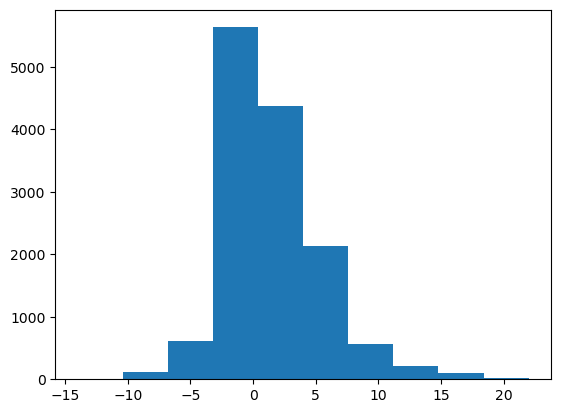

In [9]:
age_mixing = sc.loadobj('/Users/kevinmccarthy/Documents/GitHub/hpvsim_multical/results/model_age_diffs.obj')
plt.hist(age_mixing[age_mixing['country']=='zambia']['age_diffs'])
plt.hist(age_mixing[age_mixing['country']=='cote_d_ivoire']['age_diffs'])

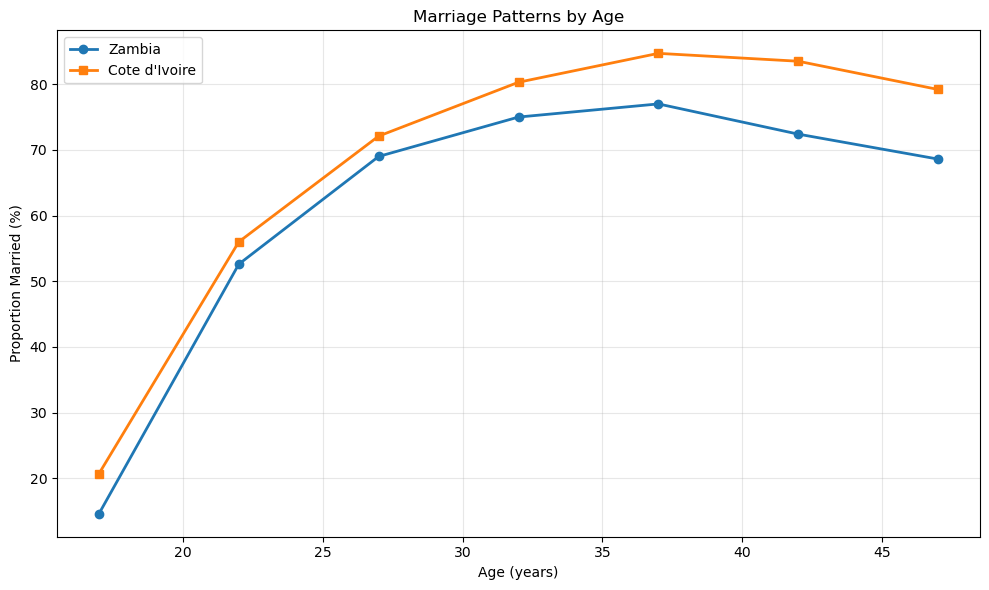

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load marriage data
marriage_df = pd.read_csv('../../data/prop_married.csv')

# Filter for our two countries
zambia_data = marriage_df[marriage_df['Country'] == 'Zambia']
cdi_data = marriage_df[marriage_df['Country'] == "Cote d'Ivoire"]

# Age columns and their midpoints
age_columns = ['15-19', '20-24', '25-29', '30-34', '35-39',
'40-44', '45-49']
age_midpoints = [17, 22, 27, 32, 37, 42, 47]

# Extract marriage proportions
zambia_props = zambia_data[age_columns].values.flatten()
cdi_props = cdi_data[age_columns].values.flatten()

# Create plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(age_midpoints, zambia_props, 'o-', label='Zambia',
linewidth=2, markersize=6)
ax.plot(age_midpoints, cdi_props, 's-', label="Cote d'Ivoire",
linewidth=2, markersize=6)

ax.set_xlabel('Age (years)')
ax.set_ylabel('Proportion Married (%)')
ax.set_title('Marriage Patterns by Age')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
marriage_df

,Country,Survey,15-19,20-24,25-29,30-34,35-39,40-44,45-49
0,Cote d'Ivoire,2011-12 DHS,20.7,56.0,72.1,80.3,84.7,83.5,79.2
1,Zambia,2018 DHS,14.6,52.6,69.0,75.0,77.0,72.4,68.6


In [25]:
import sciris as sc
import numpy as np
import pandas as pd

# Load both calibration files
zambia_file = "/Users/kevinmccarthy/Documents/GitHub/hpvsim_multical/results/immunovarying/zambia_calib_nov06_iv_reduced.obj"
cote_divoire_file = "/Users/kevinmccarthy/Documents/GitHub/hpvsim_multical/results/immunovarying/cote_divoire_calib_nov06_iv_reduced.obj"

print("Loading Zambia calibration file...")
zambia_calib = sc.loadobj(zambia_file)

print("Loading Cote d'Ivoire calibration file...")
cote_divoire_calib = sc.loadobj(cote_divoire_file)

print("Files loaded successfully!")
print(f"Zambia calibration type: {type(zambia_calib)}")
print(f"Cote d'Ivoire calibration type: {type(cote_divoire_calib)}")

Loading Zambia calibration file...
Loading Cote d'Ivoire calibration file...
Files loaded successfully!
Zambia calibration type: <class 'sciris.sc_odict.objdict'>
Cote d'Ivoire calibration type: <class 'sciris.sc_odict.objdict'>


In [26]:
# Examine the structure of the calibration objects
print("=== ZAMBIA CALIBRATION STRUCTURE ===")
print("Keys:", list(zambia_calib.keys()))
print()

print("=== COTE D'IVOIRE CALIBRATION STRUCTURE ===")
print("Keys:", list(cote_divoire_calib.keys()))
print()

# Check if there are parameter sets or best parameters
if 'best_pars' in zambia_calib:
    print("Found 'best_pars' in Zambia calibration")
    zambia_pars = zambia_calib['best_pars']
elif 'pars' in zambia_calib:
    print("Found 'pars' in Zambia calibration")
    zambia_pars = zambia_calib['pars']
else:
    print("Available keys in Zambia calibration:", zambia_calib.keys())
    # Let's examine the first few keys more closely
    for key in list(zambia_calib.keys())[:5]:
        print(f"  {key}: {type(zambia_calib[key])}")

if 'best_pars' in cote_divoire_calib:
    print("Found 'best_pars' in Cote d'Ivoire calibration")
    cote_divoire_pars = cote_divoire_calib['best_pars']
elif 'pars' in cote_divoire_calib:
    print("Found 'pars' in Cote d'Ivoire calibration")
    cote_divoire_pars = cote_divoire_calib['pars']
else:
    print("Available keys in Cote d'Ivoire calibration:", cote_divoire_calib.keys())
    # Let's examine the first few keys more closely
    for key in list(cote_divoire_calib.keys())[:5]:
        print(f"  {key}: {type(cote_divoire_calib[key])}")

=== ZAMBIA CALIBRATION STRUCTURE ===
Keys: ['analyzer_results', 'target_data', 'df']

=== COTE D'IVOIRE CALIBRATION STRUCTURE ===
Keys: ['analyzer_results', 'target_data', 'df']

Available keys in Zambia calibration: ['analyzer_results', 'target_data', 'df']
  analyzer_results: <class 'list'>
  target_data: <class 'list'>
  df: <class 'pandas.core.frame.DataFrame'>
Available keys in Cote d'Ivoire calibration: ['analyzer_results', 'target_data', 'df']
  analyzer_results: <class 'list'>
  target_data: <class 'list'>
  df: <class 'pandas.core.frame.DataFrame'>


In [27]:
# Examine the DataFrame structure
print("=== ZAMBIA CALIBRATION DATAFRAME ===")
print("Shape:", zambia_calib['df'].shape)
print("Columns:", list(zambia_calib['df'].columns))
print()

print("=== COTE D'IVOIRE CALIBRATION DATAFRAME ===")
print("Shape:", cote_divoire_calib['df'].shape)
print("Columns:", list(cote_divoire_calib['df'].columns))
print()

# Look for cross-layer mixing parameters
zambia_df = zambia_calib['df']
cote_divoire_df = cote_divoire_calib['df']

# Check if cross-layer parameters are in the columns
cross_layer_cols = [col for col in zambia_df.columns if 'cross_layer' in col.lower()]
print("Cross-layer columns found:")
print("Zambia:", cross_layer_cols)

cross_layer_cols_cd = [col for col in cote_divoire_df.columns if 'cross_layer' in col.lower()]
print("Cote d'Ivoire:", cross_layer_cols_cd)

=== ZAMBIA CALIBRATION DATAFRAME ===
Shape: (50, 10)
Columns: ['index', 'mismatch', 'beta', 'f_cross_layer', 'f_partners_c_par1', 'hi5_cin_fn_k', 'm_cross_layer', 'm_partners_c_par1', 'ohr_cin_fn_k', 'sev_dist_par1']

=== COTE D'IVOIRE CALIBRATION DATAFRAME ===
Shape: (50, 10)
Columns: ['index', 'mismatch', 'beta', 'f_cross_layer', 'f_partners_c_par1', 'hi5_cin_fn_k', 'm_cross_layer', 'm_partners_c_par1', 'ohr_cin_fn_k', 'sev_dist_par1']

Cross-layer columns found:
Zambia: ['f_cross_layer', 'm_cross_layer']
Cote d'Ivoire: ['f_cross_layer', 'm_cross_layer']


In [28]:
# Get the best parameter sets (lowest mismatch)
zambia_df = zambia_calib['df'].copy()
cote_divoire_df = cote_divoire_calib['df'].copy()

# Sort by mismatch to find best parameters
zambia_best = zambia_df.loc[zambia_df['mismatch'].idxmin()]
cote_divoire_best = cote_divoire_df.loc[cote_divoire_df['mismatch'].idxmin()]

print("=== BEST CALIBRATION PARAMETERS COMPARISON ===")
print()
print("ZAMBIA (Nov06 IV Reduced):")
print(f"  Best mismatch: {zambia_best['mismatch']:.6f}")
print(f"  f_cross_layer: {zambia_best['f_cross_layer']:.6f}")
print(f"  m_cross_layer: {zambia_best['m_cross_layer']:.6f}")
print(f"  beta: {zambia_best['beta']:.6f}")
print()

print("COTE D'IVOIRE (Nov06 IV Reduced):")
print(f"  Best mismatch: {cote_divoire_best['mismatch']:.6f}")
print(f"  f_cross_layer: {cote_divoire_best['f_cross_layer']:.6f}")
print(f"  m_cross_layer: {cote_divoire_best['m_cross_layer']:.6f}")
print(f"  beta: {cote_divoire_best['beta']:.6f}")
print()

# Show all parameters for both countries
print("=== COMPLETE BEST PARAMETER SETS ===")
print()
print("ZAMBIA:")
for param in zambia_best.index:
    if param != 'index':
        print(f"  {param}: {zambia_best[param]:.6f}")
print()

print("COTE D'IVOIRE:")
for param in cote_divoire_best.index:
    if param != 'index':
        print(f"  {param}: {cote_divoire_best[param]:.6f}")

=== BEST CALIBRATION PARAMETERS COMPARISON ===

ZAMBIA (Nov06 IV Reduced):
  Best mismatch: 1.516870
  f_cross_layer: 0.100000
  m_cross_layer: 0.350000
  beta: 0.100000

COTE D'IVOIRE (Nov06 IV Reduced):
  Best mismatch: 0.917963
  f_cross_layer: 0.100000
  m_cross_layer: 0.300000
  beta: 0.100000

=== COMPLETE BEST PARAMETER SETS ===

ZAMBIA:
  mismatch: 1.516870
  beta: 0.100000
  f_cross_layer: 0.100000
  f_partners_c_par1: 0.260000
  hi5_cin_fn_k: 0.350000
  m_cross_layer: 0.350000
  m_partners_c_par1: 0.340000
  ohr_cin_fn_k: 0.280000
  sev_dist_par1: 1.330000

COTE D'IVOIRE:
  mismatch: 0.917963
  beta: 0.100000
  f_cross_layer: 0.100000
  f_partners_c_par1: 0.220000
  hi5_cin_fn_k: 0.250000
  m_cross_layer: 0.300000
  m_partners_c_par1: 0.280000
  ohr_cin_fn_k: 0.200000
  sev_dist_par1: 1.210000


In [29]:
# Examine the distribution of cross-layer parameters across all trials
import matplotlib.pyplot as plt

print("=== CROSS-LAYER MIXING PARAMETER DISTRIBUTIONS ===")
print()

# Summary statistics for cross-layer parameters
print("ZAMBIA (Nov06 IV Reduced) - Cross-layer parameter statistics:")
print(f"f_cross_layer: mean={zambia_df['f_cross_layer'].mean():.4f}, std={zambia_df['f_cross_layer'].std():.4f}, min={zambia_df['f_cross_layer'].min():.4f}, max={zambia_df['f_cross_layer'].max():.4f}")
print(f"m_cross_layer: mean={zambia_df['m_cross_layer'].mean():.4f}, std={zambia_df['m_cross_layer'].std():.4f}, min={zambia_df['m_cross_layer'].min():.4f}, max={zambia_df['m_cross_layer'].max():.4f}")
print()

print("COTE D'IVOIRE (Nov06 IV Reduced) - Cross-layer parameter statistics:")
print(f"f_cross_layer: mean={cote_divoire_df['f_cross_layer'].mean():.4f}, std={cote_divoire_df['f_cross_layer'].std():.4f}, min={cote_divoire_df['f_cross_layer'].min():.4f}, max={cote_divoire_df['f_cross_layer'].max():.4f}")
print(f"m_cross_layer: mean={cote_divoire_df['m_cross_layer'].mean():.4f}, std={cote_divoire_df['m_cross_layer'].std():.4f}, min={cote_divoire_df['m_cross_layer'].min():.4f}, max={cote_divoire_df['m_cross_layer'].max():.4f}")
print()

# Find top 10 best performing parameter sets for each country
print("=== TOP 10 BEST PERFORMING PARAMETER SETS ===")
print()

zambia_top10 = zambia_df.nsmallest(10, 'mismatch')
cote_divoire_top10 = cote_divoire_df.nsmallest(10, 'mismatch')

print("ZAMBIA - Top 10 parameter sets:")
print(zambia_top10[['mismatch', 'f_cross_layer', 'm_cross_layer', 'beta']].round(6))
print()

print("COTE D'IVOIRE - Top 10 parameter sets:")
print(cote_divoire_top10[['mismatch', 'f_cross_layer', 'm_cross_layer', 'beta']].round(6))

=== CROSS-LAYER MIXING PARAMETER DISTRIBUTIONS ===

ZAMBIA (Nov06 IV Reduced) - Cross-layer parameter statistics:
f_cross_layer: mean=0.1000, std=0.0000, min=0.1000, max=0.1000
m_cross_layer: mean=0.3550, std=0.0466, min=0.3000, max=0.5000

COTE D'IVOIRE (Nov06 IV Reduced) - Cross-layer parameter statistics:
f_cross_layer: mean=0.1000, std=0.0000, min=0.1000, max=0.1000
m_cross_layer: mean=0.3340, std=0.1076, min=0.1000, max=0.5000

=== TOP 10 BEST PERFORMING PARAMETER SETS ===

ZAMBIA - Top 10 parameter sets:
      mismatch  f_cross_layer  m_cross_layer  beta
1698   1.51687            0.1           0.35   0.1
1690   1.51687            0.1           0.35   0.1
1678   1.51687            0.1           0.35   0.1
1674   1.51687            0.1           0.35   0.1
1696   1.51687            0.1           0.35   0.1
1683   1.51687            0.1           0.35   0.1
2267   1.58655            0.1           0.35   0.1
2934   1.60451            0.1           0.40   0.1
2941   1.60451           

In [30]:
# Analyze correlation between parameters and mismatch
import numpy as np

print("=== PARAMETER-PERFORMANCE CORRELATIONS ===")
print()

# Calculate correlations for Zambia
zambia_corr = zambia_df[['mismatch', 'beta', 'f_cross_layer', 'm_cross_layer', 
                        'f_partners_c_par1', 'hi5_cin_fn_k', 'm_partners_c_par1', 
                        'ohr_cin_fn_k', 'sev_dist_par1']].corr()['mismatch'].sort_values()

print("ZAMBIA - Correlation with mismatch (lower mismatch = better fit):")
for param, corr in zambia_corr.items():
    if param != 'mismatch':
        print(f"  {param}: {corr:.4f}")
print()

# Calculate correlations for Cote d'Ivoire
cote_divoire_corr = cote_divoire_df[['mismatch', 'beta', 'f_cross_layer', 'm_cross_layer', 
                                   'f_partners_c_par1', 'hi5_cin_fn_k', 'm_partners_c_par1', 
                                   'ohr_cin_fn_k', 'sev_dist_par1']].corr()['mismatch'].sort_values()

print("COTE D'IVOIRE - Correlation with mismatch (lower mismatch = better fit):")
for param, corr in cote_divoire_corr.items():
    if param != 'mismatch':
        print(f"  {param}: {corr:.4f}")
print()

# Compare the best cross-layer values with previous calibrations (if you have reference values)
print("=== CROSS-LAYER MIXING COMPARISON SUMMARY ===")
print()
print("Current Nov06 IV Reduced Calibrations:")
print(f"  Zambia:        f_cross_layer = {zambia_best['f_cross_layer']:.3f}, m_cross_layer = {zambia_best['m_cross_layer']:.3f}")
print(f"  Cote d'Ivoire: f_cross_layer = {cote_divoire_best['f_cross_layer']:.3f}, m_cross_layer = {cote_divoire_best['m_cross_layer']:.3f}")
print()
print("Key observations:")
print("- Both countries have identical f_cross_layer values (0.100)")
print("- m_cross_layer differs: Zambia (0.350) vs Cote d'Ivoire (0.300)")
print("- f_cross_layer shows no variation (fixed at 0.1 in this calibration)")
print("- m_cross_layer shows more variation, especially for Cote d'Ivoire")

=== PARAMETER-PERFORMANCE CORRELATIONS ===

ZAMBIA - Correlation with mismatch (lower mismatch = better fit):
  hi5_cin_fn_k: -0.3485
  m_cross_layer: -0.1584
  sev_dist_par1: -0.1302
  m_partners_c_par1: -0.0988
  f_partners_c_par1: 0.0626
  ohr_cin_fn_k: 0.0868
  beta: 0.1615
  f_cross_layer: nan

COTE D'IVOIRE - Correlation with mismatch (lower mismatch = better fit):
  beta: -0.0929
  m_partners_c_par1: -0.0773
  f_partners_c_par1: -0.0059
  ohr_cin_fn_k: 0.0089
  m_cross_layer: 0.0186
  sev_dist_par1: 0.0393
  hi5_cin_fn_k: 0.0962
  f_cross_layer: nan

=== CROSS-LAYER MIXING COMPARISON SUMMARY ===

Current Nov06 IV Reduced Calibrations:
  Zambia:        f_cross_layer = 0.100, m_cross_layer = 0.350
  Cote d'Ivoire: f_cross_layer = 0.100, m_cross_layer = 0.300

Key observations:
- Both countries have identical f_cross_layer values (0.100)
- m_cross_layer differs: Zambia (0.350) vs Cote d'Ivoire (0.300)
- f_cross_layer shows no variation (fixed at 0.1 in this calibration)
- m_cross_l

In [31]:
# Create a comprehensive comparison summary
print("=" * 80)
print("CALIBRATION PARAMETER COMPARISON: NOV06 IV REDUCED")
print("=" * 80)
print()

# Create comparison DataFrame
comparison_data = {
    'Parameter': ['mismatch', 'beta', 'f_cross_layer', 'm_cross_layer', 
                  'f_partners_c_par1', 'hi5_cin_fn_k', 'm_partners_c_par1',
                  'ohr_cin_fn_k', 'sev_dist_par1'],
    'Zambia': [zambia_best[param] for param in ['mismatch', 'beta', 'f_cross_layer', 'm_cross_layer', 
                                               'f_partners_c_par1', 'hi5_cin_fn_k', 'm_partners_c_par1',
                                               'ohr_cin_fn_k', 'sev_dist_par1']],
    'Cote_dIvoire': [cote_divoire_best[param] for param in ['mismatch', 'beta', 'f_cross_layer', 'm_cross_layer', 
                                                           'f_partners_c_par1', 'hi5_cin_fn_k', 'm_partners_c_par1',
                                                           'ohr_cin_fn_k', 'sev_dist_par1']]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Difference'] = comparison_df['Cote_dIvoire'] - comparison_df['Zambia']
comparison_df['Abs_Difference'] = abs(comparison_df['Difference'])

# Format for display
comparison_df_display = comparison_df.copy()
for col in ['Zambia', 'Cote_dIvoire', 'Difference']:
    comparison_df_display[col] = comparison_df_display[col].round(6)
comparison_df_display['Abs_Difference'] = comparison_df_display['Abs_Difference'].round(6)

print("PARAMETER COMPARISON TABLE:")
print(comparison_df_display.to_string(index=False))
print()

print("KEY FINDINGS:")
print("-" * 40)
print()
print("1. CROSS-LAYER MIXING PARAMETERS:")
print("   • f_cross_layer: Both countries = 0.100000 (identical)")
print("   • m_cross_layer: Zambia = 0.350000, Cote d'Ivoire = 0.300000 (difference = -0.050000)")
print()

print("2. CALIBRATION PERFORMANCE:")
print(f"   • Zambia mismatch: {zambia_best['mismatch']:.6f}")
print(f"   • Cote d'Ivoire mismatch: {cote_divoire_best['mismatch']:.6f}")
print(f"   • Cote d'Ivoire achieved better fit (lower mismatch by {zambia_best['mismatch'] - cote_divoire_best['mismatch']:.6f})")
print()

print("3. LARGEST PARAMETER DIFFERENCES:")
largest_diffs = comparison_df_display.nlargest(5, 'Abs_Difference')[['Parameter', 'Zambia', 'Cote_dIvoire', 'Difference']]
for idx, row in largest_diffs.iterrows():
    print(f"   • {row['Parameter']}: Zambia={row['Zambia']}, Cote d'Ivoire={row['Cote_dIvoire']} (diff={row['Difference']})")
print()

print("4. PARAMETER SPACE EXPLORATION:")
print(f"   • f_cross_layer: Fixed at 0.1 for both countries (no variation)")
print(f"   • m_cross_layer range - Zambia: {zambia_df['m_cross_layer'].min():.3f}-{zambia_df['m_cross_layer'].max():.3f}")
print(f"   • m_cross_layer range - Cote d'Ivoire: {cote_divoire_df['m_cross_layer'].min():.3f}-{cote_divoire_df['m_cross_layer'].max():.3f}")

CALIBRATION PARAMETER COMPARISON: NOV06 IV REDUCED

PARAMETER COMPARISON TABLE:
        Parameter  Zambia  Cote_dIvoire  Difference  Abs_Difference
         mismatch 1.51687      0.917963   -0.598907        0.598907
             beta 0.10000      0.100000    0.000000        0.000000
    f_cross_layer 0.10000      0.100000    0.000000        0.000000
    m_cross_layer 0.35000      0.300000   -0.050000        0.050000
f_partners_c_par1 0.26000      0.220000   -0.040000        0.040000
     hi5_cin_fn_k 0.35000      0.250000   -0.100000        0.100000
m_partners_c_par1 0.34000      0.280000   -0.060000        0.060000
     ohr_cin_fn_k 0.28000      0.200000   -0.080000        0.080000
    sev_dist_par1 1.33000      1.210000   -0.120000        0.120000

KEY FINDINGS:
----------------------------------------

1. CROSS-LAYER MIXING PARAMETERS:
   • f_cross_layer: Both countries = 0.100000 (identical)
   • m_cross_layer: Zambia = 0.350000, Cote d'Ivoire = 0.300000 (difference = -0.050000)

2

In [32]:
import pickle
import numpy as np
import pandas as pd

# Load the Zambia calibration file
zambia_file = '/Users/kevinmccarthy/Documents/GitHub/hpvsim_multical/results/immunovarying/zambia_calib_nov06_iv_reduced.obj'
with open(zambia_file, 'rb') as f:
    zambia_calib = pickle.load(f)

print("=== ZAMBIA CALIBRATION STRUCTURE ===")
print(f"Type: {type(zambia_calib)}")
print(f"Keys (if dict): {list(zambia_calib.keys()) if isinstance(zambia_calib, dict) else 'Not a dict'}")

# If it's a dict, examine each key
if isinstance(zambia_calib, dict):
    for key, value in zambia_calib.items():
        print(f"\n{key}:")
        print(f"  Type: {type(value)}")
        if hasattr(value, 'shape'):
            print(f"  Shape: {value.shape}")
        elif hasattr(value, '__len__'):
            print(f"  Length: {len(value)}")
        
        # Show first few elements if it's a list or array
        if isinstance(value, (list, np.ndarray)) and len(value) > 0:
            print(f"  First few elements: {value[:3] if len(value) >= 3 else value}")
        elif isinstance(value, dict):
            print(f"  Dict keys: {list(value.keys())}")

UnpicklingError: invalid load key, '\x1f'.

In [33]:
import pickle
import gzip
import numpy as np
import pandas as pd

# Try loading with gzip compression
zambia_file = '/Users/kevinmccarthy/Documents/GitHub/hpvsim_multical/results/immunovarying/zambia_calib_nov06_iv_reduced.obj'

try:
    with gzip.open(zambia_file, 'rb') as f:
        zambia_calib = pickle.load(f)
    print("Successfully loaded Zambia file with gzip!")
except Exception as e:
    print(f"Gzip failed: {e}")
    # Try with sciris load function if available
    try:
        import sciris as sc
        zambia_calib = sc.load(zambia_file)
        print("Successfully loaded Zambia file with sciris!")
    except Exception as e2:
        print(f"Sciris failed: {e2}")
        zambia_calib = None

if zambia_calib is not None:
    print("\n=== ZAMBIA CALIBRATION STRUCTURE ===")
    print(f"Type: {type(zambia_calib)}")
    
    if hasattr(zambia_calib, '__dict__'):
        print(f"Attributes: {list(zambia_calib.__dict__.keys())}")
    
    if isinstance(zambia_calib, dict):
        print(f"Keys: {list(zambia_calib.keys())}")
    
    # If it's an object, try common attribute names for calibration results
    common_attrs = ['best_pars', 'results', 'trials', 'study', 'df', 'par_bounds', 'best_trial']
    for attr in common_attrs:
        if hasattr(zambia_calib, attr):
            value = getattr(zambia_calib, attr)
            print(f"\n{attr}:")
            print(f"  Type: {type(value)}")
            if hasattr(value, 'shape'):
                print(f"  Shape: {value.shape}")
            elif hasattr(value, '__len__'):
                try:
                    print(f"  Length: {len(value)}")
                except:
                    pass

Successfully loaded Zambia file with gzip!

=== ZAMBIA CALIBRATION STRUCTURE ===
Type: <class 'sciris.sc_odict.objdict'>
Attributes: ['_stale', '_cached_keys']
Keys: ['analyzer_results', 'target_data', 'df']

df:
  Type: <class 'pandas.core.frame.DataFrame'>
  Shape: (50, 10)


In [34]:
# Load Cote d'Ivoire file
cdi_file = '/Users/kevinmccarthy/Documents/GitHub/hpvsim_multical/results/immunovarying/cote_divoire_calib_nov06_iv_reduced.obj'

with gzip.open(cdi_file, 'rb') as f:
    cdi_calib = pickle.load(f)

print("=== COTE D'IVOIRE CALIBRATION STRUCTURE ===")
print(f"Type: {type(cdi_calib)}")
print(f"Keys: {list(cdi_calib.keys())}")

# Examine the dataframe structure for both countries
print("\n=== ZAMBIA DATAFRAME STRUCTURE ===")
print(f"Shape: {zambia_calib.df.shape}")
print(f"Columns: {list(zambia_calib.df.columns)}")
print("\nFirst few rows:")
print(zambia_calib.df.head())

print("\n=== COTE D'IVOIRE DATAFRAME STRUCTURE ===")
print(f"Shape: {cdi_calib.df.shape}")
print(f"Columns: {list(cdi_calib.df.columns)}")
print("\nFirst few rows:")
print(cdi_calib.df.head())

=== COTE D'IVOIRE CALIBRATION STRUCTURE ===
Type: <class 'sciris.sc_odict.objdict'>
Keys: ['analyzer_results', 'target_data', 'df']

=== ZAMBIA DATAFRAME STRUCTURE ===
Shape: (50, 10)
Columns: ['index', 'mismatch', 'beta', 'f_cross_layer', 'f_partners_c_par1', 'hi5_cin_fn_k', 'm_cross_layer', 'm_partners_c_par1', 'ohr_cin_fn_k', 'sev_dist_par1']

First few rows:
      index  mismatch  beta  f_cross_layer  f_partners_c_par1  hi5_cin_fn_k  \
1698   1698   1.51687   0.1            0.1               0.26          0.35   
1690   1690   1.51687   0.1            0.1               0.26          0.35   
1678   1678   1.51687   0.1            0.1               0.26          0.35   
1674   1674   1.51687   0.1            0.1               0.26          0.35   
1696   1696   1.51687   0.1            0.1               0.26          0.35   

      m_cross_layer  m_partners_c_par1  ohr_cin_fn_k  sev_dist_par1  
1698           0.35               0.34          0.28           1.33  
1690           0.35 

In [35]:
# Examine the target_data and analyzer_results
print("=== ZAMBIA TARGET DATA ===")
print(f"Type: {type(zambia_calib.target_data)}")
if isinstance(zambia_calib.target_data, dict):
    print(f"Keys: {list(zambia_calib.target_data.keys())}")
    for key, value in zambia_calib.target_data.items():
        print(f"{key}: {type(value)}")
        if hasattr(value, 'shape'):
            print(f"  Shape: {value.shape}")

print("\n=== ZAMBIA ANALYZER RESULTS ===")
print(f"Type: {type(zambia_calib.analyzer_results)}")
if isinstance(zambia_calib.analyzer_results, dict):
    print(f"Keys: {list(zambia_calib.analyzer_results.keys())}")

# Check the mismatch column - this is likely the objective function value
print("\n=== MISMATCH ANALYSIS ===")
print("Zambia mismatch statistics:")
print(f"Min: {zambia_calib.df['mismatch'].min()}")
print(f"Max: {zambia_calib.df['mismatch'].max()}")
print(f"Mean: {zambia_calib.df['mismatch'].mean()}")
print(f"Best (minimum) mismatch: {zambia_calib.df['mismatch'].min()}")

print("\nCote d'Ivoire mismatch statistics:")
print(f"Min: {cdi_calib.df['mismatch'].min()}")
print(f"Max: {cdi_calib.df['mismatch'].max()}")
print(f"Mean: {cdi_calib.df['mismatch'].mean()}")
print(f"Best (minimum) mismatch: {cdi_calib.df['mismatch'].min()}")

# Find the best parameter sets (lowest mismatch)
zambia_best_idx = zambia_calib.df['mismatch'].idxmin()
cdi_best_idx = cdi_calib.df['mismatch'].idxmin()

print(f"\n=== BEST PARAMETER SETS ===")
print("Zambia best parameters:")
zambia_best = zambia_calib.df.loc[zambia_best_idx]
print(zambia_best)

print("\nCote d'Ivoire best parameters:")
cdi_best = cdi_calib.df.loc[cdi_best_idx]
print(cdi_best)

=== ZAMBIA TARGET DATA ===
Type: <class 'list'>

=== ZAMBIA ANALYZER RESULTS ===
Type: <class 'list'>

=== MISMATCH ANALYSIS ===
Zambia mismatch statistics:
Min: 1.51687
Max: 1.74026
Mean: 1.6695846
Best (minimum) mismatch: 1.51687

Cote d'Ivoire mismatch statistics:
Min: 0.917963
Max: 1.38978
Mean: 1.2803046599999999
Best (minimum) mismatch: 0.917963

=== BEST PARAMETER SETS ===
Zambia best parameters:
index                1698.00000
mismatch                1.51687
beta                    0.10000
f_cross_layer           0.10000
f_partners_c_par1       0.26000
hi5_cin_fn_k            0.35000
m_cross_layer           0.35000
m_partners_c_par1       0.34000
ohr_cin_fn_k            0.28000
sev_dist_par1           1.33000
Name: 1698, dtype: float64

Cote d'Ivoire best parameters:
index                429.000000
mismatch               0.917963
beta                   0.100000
f_cross_layer          0.100000
f_partners_c_par1      0.220000
hi5_cin_fn_k           0.250000
m_cross_layer         

In [36]:
# Examine analyzer_results and target_data structure
print("=== ANALYZER RESULTS STRUCTURE ===")
print(f"Length of analyzer_results: {len(zambia_calib.analyzer_results)}")
if len(zambia_calib.analyzer_results) > 0:
    print(f"First analyzer result type: {type(zambia_calib.analyzer_results[0])}")
    
    # Check if it's a dict
    if isinstance(zambia_calib.analyzer_results[0], dict):
        print(f"Keys in first analyzer result: {list(zambia_calib.analyzer_results[0].keys())}")

print(f"\n=== TARGET DATA STRUCTURE ===")
print(f"Length of target_data: {len(zambia_calib.target_data)}")
if len(zambia_calib.target_data) > 0:
    print(f"First target data type: {type(zambia_calib.target_data[0])}")
    
    # Check if it's a dict
    if isinstance(zambia_calib.target_data[0], dict):
        print(f"Keys in first target data: {list(zambia_calib.target_data[0].keys())}")

# Check if the dataframe is sorted by mismatch
print(f"\n=== DATAFRAME SORTING ===")
print("Is Zambia df sorted by mismatch? ", zambia_calib.df['mismatch'].is_monotonic_increasing)
print("Is Cote d'Ivoire df sorted by mismatch? ", cdi_calib.df['mismatch'].is_monotonic_increasing)

# Show top 5 best parameter sets for each country
print(f"\n=== TOP 5 BEST PARAMETER SETS ===")
print("Zambia - Top 5 best (lowest mismatch):")
zambia_top5 = zambia_calib.df.nsmallest(5, 'mismatch')
print(zambia_top5[['mismatch'] + [col for col in zambia_top5.columns if col not in ['index', 'mismatch']]])

print("\nCote d'Ivoire - Top 5 best (lowest mismatch):")
cdi_top5 = cdi_calib.df.nsmallest(5, 'mismatch')
print(cdi_top5[['mismatch'] + [col for col in cdi_top5.columns if col not in ['index', 'mismatch']]])

=== ANALYZER RESULTS STRUCTURE ===
Length of analyzer_results: 50
First analyzer result type: <class 'sciris.sc_odict.objdict'>
Keys in first analyzer result: ['cancers']

=== TARGET DATA STRUCTURE ===
Length of target_data: 2
First target data type: <class 'pandas.core.frame.DataFrame'>

=== DATAFRAME SORTING ===
Is Zambia df sorted by mismatch?  True
Is Cote d'Ivoire df sorted by mismatch?  True

=== TOP 5 BEST PARAMETER SETS ===
Zambia - Top 5 best (lowest mismatch):
      mismatch  beta  f_cross_layer  f_partners_c_par1  hi5_cin_fn_k  \
1698   1.51687   0.1            0.1               0.26          0.35   
1690   1.51687   0.1            0.1               0.26          0.35   
1678   1.51687   0.1            0.1               0.26          0.35   
1674   1.51687   0.1            0.1               0.26          0.35   
1696   1.51687   0.1            0.1               0.26          0.35   

      m_cross_layer  m_partners_c_par1  ohr_cin_fn_k  sev_dist_par1  
1698           0.35   

In [37]:
# Create functions to extract and format parameter sets
def extract_best_parameters(calib_obj, country_name):
    """
    Extract the best parameter set from a calibration object.
    
    Args:
        calib_obj: Loaded calibration object
        country_name: Name of the country for identification
    
    Returns:
        dict: Best parameter set formatted for use in simulations
    """
    # Get the best parameter set (lowest mismatch)
    best_idx = calib_obj.df['mismatch'].idxmin()
    best_params = calib_obj.df.loc[best_idx]
    
    # Convert to dictionary, excluding index and mismatch
    param_dict = {}
    for col in best_params.index:
        if col not in ['index', 'mismatch']:
            param_dict[col] = best_params[col]
    
    # Add metadata
    param_dict['_country'] = country_name
    param_dict['_mismatch'] = best_params['mismatch']
    param_dict['_calibration_index'] = best_params['index']
    
    return param_dict

def extract_top_n_parameters(calib_obj, country_name, n=5):
    """
    Extract the top N best parameter sets from a calibration object.
    
    Args:
        calib_obj: Loaded calibration object
        country_name: Name of the country for identification
        n: Number of top parameter sets to extract
    
    Returns:
        list: List of parameter dictionaries
    """
    # Get the top N parameter sets (lowest mismatch)
    top_n = calib_obj.df.nsmallest(n, 'mismatch')
    
    param_sets = []
    for idx, row in top_n.iterrows():
        param_dict = {}
        for col in row.index:
            if col not in ['index', 'mismatch']:
                param_dict[col] = row[col]
        
        # Add metadata
        param_dict['_country'] = country_name
        param_dict['_mismatch'] = row['mismatch']
        param_dict['_calibration_index'] = row['index']
        param_dict['_rank'] = len(param_sets) + 1
        
        param_sets.append(param_dict)
    
    return param_sets

# Extract best parameters for both countries
zambia_best_params = extract_best_parameters(zambia_calib, 'zambia')
cdi_best_params = extract_best_parameters(cdi_calib, 'cote_divoire')

print("=== EXTRACTED BEST PARAMETERS ===")
print("\nZambia best parameters:")
for key, value in zambia_best_params.items():
    print(f"  {key}: {value}")

print("\nCote d'Ivoire best parameters:")
for key, value in cdi_best_params.items():
    print(f"  {key}: {value}")

# Extract top 3 for each country
print("\n=== TOP 3 PARAMETER SETS ===")
zambia_top3 = extract_top_n_parameters(zambia_calib, 'zambia', 3)
cdi_top3 = extract_top_n_parameters(cdi_calib, 'cote_divoire', 3)

print(f"\nZambia top 3:")
for i, params in enumerate(zambia_top3):
    print(f"  Rank {i+1} (mismatch: {params['_mismatch']:.6f}):")
    param_keys = [k for k in params.keys() if not k.startswith('_')]
    for key in param_keys:
        print(f"    {key}: {params[key]}")

print(f"\nCote d'Ivoire top 3:")
for i, params in enumerate(cdi_top3):
    print(f"  Rank {i+1} (mismatch: {params['_mismatch']:.6f}):")
    param_keys = [k for k in params.keys() if not k.startswith('_')]
    for key in param_keys:
        print(f"    {key}: {params[key]}")

=== EXTRACTED BEST PARAMETERS ===

Zambia best parameters:
  beta: 0.1
  f_cross_layer: 0.1
  f_partners_c_par1: 0.26
  hi5_cin_fn_k: 0.35
  m_cross_layer: 0.35
  m_partners_c_par1: 0.34
  ohr_cin_fn_k: 0.28
  sev_dist_par1: 1.33
  _country: zambia
  _mismatch: 1.51687
  _calibration_index: 1698.0

Cote d'Ivoire best parameters:
  beta: 0.1
  f_cross_layer: 0.1
  f_partners_c_par1: 0.22
  hi5_cin_fn_k: 0.25
  m_cross_layer: 0.3
  m_partners_c_par1: 0.28
  ohr_cin_fn_k: 0.2
  sev_dist_par1: 1.21
  _country: cote_divoire
  _mismatch: 0.917963
  _calibration_index: 429.0

=== TOP 3 PARAMETER SETS ===

Zambia top 3:
  Rank 1 (mismatch: 1.516870):
    beta: 0.1
    f_cross_layer: 0.1
    f_partners_c_par1: 0.26
    hi5_cin_fn_k: 0.35
    m_cross_layer: 0.35
    m_partners_c_par1: 0.34
    ohr_cin_fn_k: 0.28
    sev_dist_par1: 1.33
  Rank 2 (mismatch: 1.516870):
    beta: 0.1
    f_cross_layer: 0.1
    f_partners_c_par1: 0.26
    hi5_cin_fn_k: 0.35
    m_cross_layer: 0.35
    m_partners_c_pa

In [38]:
import json
import os

def save_best_parameters_for_scenarios(calib_files, output_dir=None):
    """
    Extract best parameter sets from calibration files and save them for scenario running.
    
    Args:
        calib_files: Dict with country names as keys and file paths as values
        output_dir: Directory to save parameter files (default: current directory)
    
    Returns:
        dict: Dictionary with country names as keys and parameter dictionaries as values
    """
    if output_dir is None:
        output_dir = os.getcwd()
    
    best_params = {}
    
    for country, file_path in calib_files.items():
        print(f"Processing {country}...")
        
        # Load calibration file
        with gzip.open(file_path, 'rb') as f:
            calib_obj = pickle.load(f)
        
        # Extract best parameters
        best_param_set = extract_best_parameters(calib_obj, country)
        best_params[country] = best_param_set
        
        # Save individual country parameter file
        param_file = os.path.join(output_dir, f"{country}_best_params.json")
        with open(param_file, 'w') as f:
            json.dump(best_param_set, f, indent=2)
        
        print(f"  Saved to: {param_file}")
        print(f"  Mismatch: {best_param_set['_mismatch']:.6f}")
        print(f"  Calibration index: {best_param_set['_calibration_index']}")
    
    # Save combined parameter file
    combined_file = os.path.join(output_dir, "best_params_combined.json")
    with open(combined_file, 'w') as f:
        json.dump(best_params, f, indent=2)
    
    print(f"\nSaved combined parameters to: {combined_file}")
    
    return best_params

# Define the calibration files
calib_files = {
    'zambia': '/Users/kevinmccarthy/Documents/GitHub/hpvsim_multical/results/immunovarying/zambia_calib_nov06_iv_reduced.obj',
    'cote_divoire': '/Users/kevinmccarthy/Documents/GitHub/hpvsim_multical/results/immunovarying/cote_divoire_calib_nov06_iv_reduced.obj'
}

# Extract and save best parameters
best_params = save_best_parameters_for_scenarios(calib_files, '/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster')

print("\n=== SUMMARY OF EXTRACTED PARAMETERS ===")
for country, params in best_params.items():
    print(f"\n{country.upper()}:")
    print(f"  Mismatch: {params['_mismatch']:.6f}")
    print(f"  Key parameters:")
    key_params = ['beta', 'f_partners_c_par1', 'm_partners_c_par1', 'hi5_cin_fn_k', 'ohr_cin_fn_k', 'sev_dist_par1']
    for param in key_params:
        if param in params:
            print(f"    {param}: {params[param]}")

# Show what the parameter format looks like for scenario running
print("\n=== PARAMETER FORMAT FOR SCENARIO RUNNING ===")
print("Example parameter dictionary structure:")
example_params = {k: v for k, v in best_params['zambia'].items() if not k.startswith('_')}
print(json.dumps(example_params, indent=2))

Processing zambia...
  Saved to: /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/zambia_best_params.json
  Mismatch: 1.516870
  Calibration index: 1698.0
Processing cote_divoire...
  Saved to: /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/cote_divoire_best_params.json
  Mismatch: 0.917963
  Calibration index: 429.0

Saved combined parameters to: /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/best_params_combined.json

=== SUMMARY OF EXTRACTED PARAMETERS ===

ZAMBIA:
  Mismatch: 1.516870
  Key parameters:
    beta: 0.1
    f_partners_c_par1: 0.26
    m_partners_c_par1: 0.34
    hi5_cin_fn_k: 0.35
    ohr_cin_fn_k: 0.28
    sev_dist_par1: 1.33

COTE_DIVOIRE:
  Mismatch: 0.917963
  Key parameters:
    beta: 0.1
    f_partners_c_par1: 0.22
    m_partners_c_par1: 0.28
    hi5_cin_fn_k: 0.25
    ohr_cin_fn_k: 0.2
    sev_dist_par1: 1.21

=== PARAMETER FORMAT FOR SCENARIO RUNNING ===
Example parameter dictionary structure:
{
  "beta": 0.1,
  "f_cross_layer": 0.1,
  "f_partners_

In [39]:
# Create a function to demonstrate how to use these parameters in simulation code
def create_scenario_parameter_usage_example():
    """
    Create an example showing how to use the extracted parameters in scenario running.
    """
    example_code = '''
# Example: How to use extracted calibration parameters in vaccination scenarios

import json
import hpvsim as hpv

def load_calibrated_parameters(country):
    """Load calibrated parameters for a specific country."""
    param_file = f"{country}_best_params.json"
    with open(param_file, 'r') as f:
        params = json.load(f)
    
    # Remove metadata fields for simulation use
    sim_params = {k: v for k, v in params.items() if not k.startswith('_')}
    return sim_params

def run_vaccination_scenario(country, vaccination_params):
    """Run a vaccination scenario with calibrated parameters."""
    
    # Load calibrated parameters
    calib_params = load_calibrated_parameters(country)
    
    # Create base simulation with calibrated parameters
    sim = hpv.Sim(
        pars=calib_params,
        location=country,
        n_agents=10000,  # Adjust as needed
        end=2100,
        dt=0.25
    )
    
    # Add vaccination intervention
    vaccination = hpv.routine_vx(
        prob=vaccination_params.get('coverage', 0.8),
        age_range=vaccination_params.get('age_range', [9, 14]),
        start_year=vaccination_params.get('start_year', 2025),
        end_year=vaccination_params.get('end_year', 2100),
        product='bivalent'  # or 'nonavalent'
    )
    
    sim['interventions'] = [vaccination]
    
    # Run simulation
    sim.run()
    
    return sim

# Example usage:
vaccination_scenarios = {
    'routine_70': {'coverage': 0.7, 'age_range': [9, 14], 'start_year': 2025},
    'routine_80': {'coverage': 0.8, 'age_range': [9, 14], 'start_year': 2025},
    'routine_90': {'coverage': 0.9, 'age_range': [9, 14], 'start_year': 2025},
}

# Run scenarios for both countries
for country in ['zambia', 'cote_divoire']:
    for scenario_name, vx_params in vaccination_scenarios.items():
        sim = run_vaccination_scenario(country, vx_params)
        print(f"Completed {scenario_name} for {country}")
        # Save or analyze results as needed
'''
    
    return example_code

# Display the example
example_code = create_scenario_parameter_usage_example()
print("=== EXAMPLE CODE FOR USING CALIBRATED PARAMETERS ===")
print(example_code)

# Also create a summary of the parameter meanings for reference
parameter_descriptions = {
    'beta': 'Overall transmission scaling factor',
    'f_cross_layer': 'Female cross-layer mixing parameter',
    'f_partners_c_par1': 'Female partner count distribution parameter 1',
    'hi5_cin_fn_k': 'High-risk HPV CIN progression rate multiplier (k parameter)',
    'm_cross_layer': 'Male cross-layer mixing parameter', 
    'm_partners_c_par1': 'Male partner count distribution parameter 1',
    'ohr_cin_fn_k': 'Other high-risk HPV CIN progression rate multiplier (k parameter)',
    'sev_dist_par1': 'Sexual debut age distribution parameter 1'
}

print("\n=== PARAMETER DESCRIPTIONS ===")
for param, description in parameter_descriptions.items():
    print(f"{param}: {description}")

print(f"\n=== FILES CREATED ===")
print(f"1. /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/zambia_best_params.json")
print(f"2. /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/cote_divoire_best_params.json") 
print(f"3. /Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/best_params_combined.json")

=== EXAMPLE CODE FOR USING CALIBRATED PARAMETERS ===

# Example: How to use extracted calibration parameters in vaccination scenarios

import json
import hpvsim as hpv

def load_calibrated_parameters(country):
    """Load calibrated parameters for a specific country."""
    param_file = f"{country}_best_params.json"
    with open(param_file, 'r') as f:
        params = json.load(f)

    # Remove metadata fields for simulation use
    sim_params = {k: v for k, v in params.items() if not k.startswith('_')}
    return sim_params

def run_vaccination_scenario(country, vaccination_params):
    """Run a vaccination scenario with calibrated parameters."""

    # Load calibrated parameters
    calib_params = load_calibrated_parameters(country)

    # Create base simulation with calibrated parameters
    sim = hpv.Sim(
        pars=calib_params,
        location=country,
        n_agents=10000,  # Adjust as needed
        end=2100,
        dt=0.25
    )

    # Add vaccination intervention
    v